# Check Your Bars - Testing Normality, Independence, And Stability on Time, Tick, Volume, and Dollar Bars
 
After reading through Marcos Lopez De Prado's book, Advances in Financial Machine Learning, I was fascinated with the statistical properties of dollar bars. My curiosity led me to try out my own experiment: to analyze and compare how different methods of aggregating raw historical transaction data affect its statistical properties, specifically how normality, independence, and stability are affected when grouping raw tick data by time, ticks, amount of units traded, and amount of dollars traded.

In this article, I aggregate the raw tick data into four bar types, calculate the log returns for each, and compare how normality, independence, and stability differ between them. Once we have the returns, we can compare how close to a normal distribution the log returns follow, then see how dependent the log returns are to one another. Finally, we will run multiple tests to calculate stability and compare the results between the data.

For more information on how financial bars are constructed, please refer to this article by Gerard Martinez for tick bars and his second part for volume and dollar bars.

## Motivation

Before diving into tests, it's important to understand why we care about these properties. Many quantitative finance models (pairs trading, mean reversion, momentum strategies, risk models, etc.) make explicit assumptions about the nature of returns data. If those assumptions are violated, the models can produce incorrect signals, underestimate risk, and can lead to over-fit strategies. Verifying the data first is important in order to not waste time and computation on garbage data.

Though Prado mentions in his book that dollar bars have the best qualities of all the bars, I would also like to prove this using data and analysis of my own. While I could trust his word and continue reading, this "proof" ensures that the dollar bar data is verified to be used for modeling. If the data does not hold up statistically, neither will any model built on top of it.

## The Data

The dataset used for this comes from Kraken Time and Sales data, which can be downloaded here for free. If you would like to replicate this article, here is a github repository with a jupyter notebook, as well as custom functions to aggregate, test, and display the data.

The tick data includes the time, price, and volume for each coin traded on the exchange. Essentially, any trade executed on the exchange logs the time, price, and quantity of the instrument traded. I will use Bitcoin (BTC-USD) data from Jan 1st, 2020 to Jan 1st, 2025 for this example. This gives us a nice little sample of 59 million ticks which we can aggregate into bars and analyze. This range also includes the 2020 crash as well as the 2024 surge in Bitcoin. The regime variety and high volatility periods included will help our analysis get an overall comparison of a volatile market between bar sampling methods.

In [1]:
import pandas as pd
def load_tick_data(filepath='data/BTC_2020-2025.csv'):
    """Load and prepare tick data from CSV."""
    df = pd.read_csv(filepath, header=None, names=['time', 'price', 'volume'])
    df.columns = [col.lower().strip() for col in df.columns]
    return df
    
tick_data = load_tick_data()
print(tick_data)

                time    price    volume
0         1577836801   7168.3  0.040000
1         1577836801   7168.3  0.960000
2         1577836802   7170.5  0.002000
3         1577836804   7169.2  0.002000
4         1577836804   7169.2  0.002000
...              ...      ...       ...
59181760  1735689590  93357.3  0.075533
59181761  1735689597  93370.9  0.003603
59181762  1735689597  93370.9  0.003521
59181763  1735689597  93370.9  0.000610
59181764  1735689597  93370.9  0.001614

[59181765 rows x 3 columns]


Before we run any tests, out of curiosity I would like to analyze and compare how the bars look when displayed on a time chart. Below we compare 4-hour time bars against $10M dollar bars, both plotted over the first month of data for visibility. For this I use time and dollar bars only to represent the two extremes.

Plotting from 2020-01-01 to 2020-02-01
Time bars in window:   186
Dollar bars in window: 153


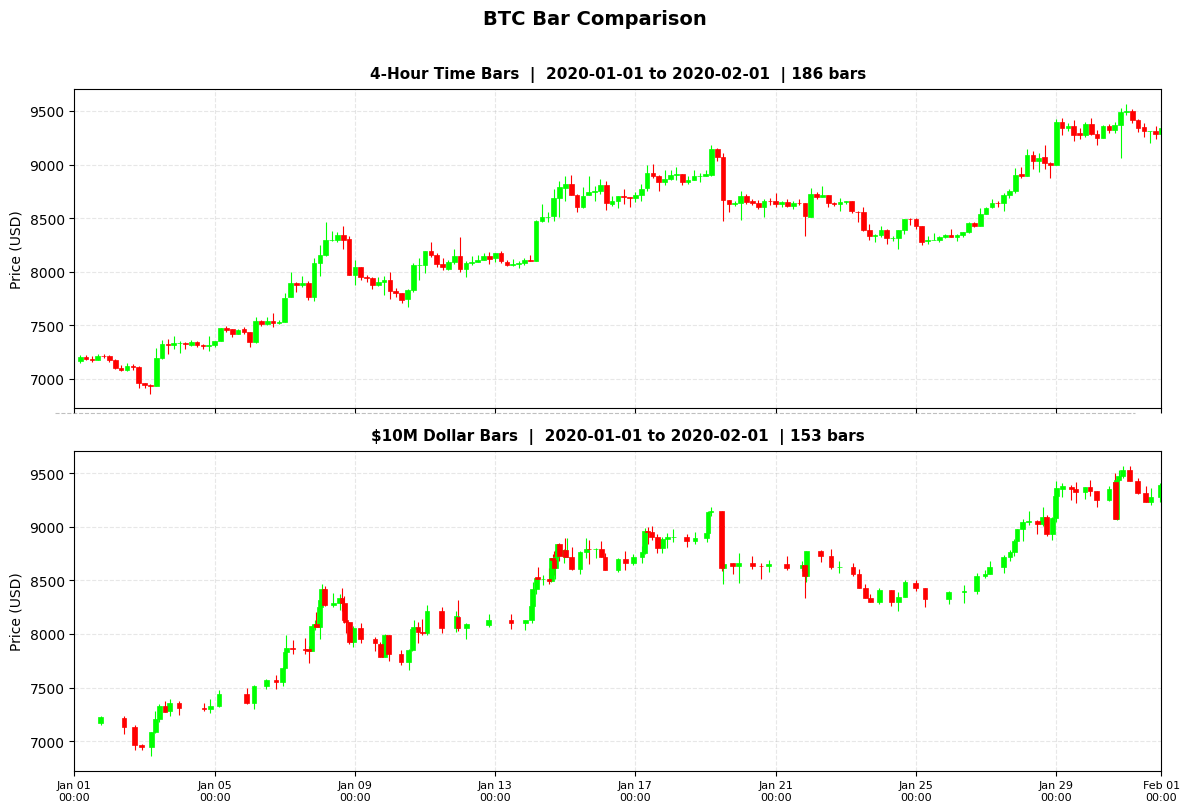

In [2]:
from src.bars import create_time_bars, create_tick_bars, create_volume_bars, create_dollar_bars
from src.visualization import plot_comparison
import matplotlib.pyplot as plt

ticks = load_tick_data('data/BTC_2020-2025.csv')

time_bars   = create_time_bars(ticks, interval=14400, fill_gaps=True)
tick_bars   = create_tick_bars(ticks, threshold=10_000)
volume_bars = create_volume_bars(ticks, threshold=1_000)
dollar_bars = create_dollar_bars(ticks, threshold=10_000_000)

fig = plot_comparison(
    time_bars=time_bars,
    dollar_bars=dollar_bars,
    start_date='2020-01-01',
    end_date='2020-02-01',
    figsize=(12, 8),
    bullish_color='#00ff00',
    bearish_color='#ff0000',
    time_bar_label="4-Hour Time Bars",
    dollar_bar_label="$10M Dollar Bars",
    show_volume=False
)
plt.savefig('bar_comparison_no_volume.png', dpi=150, bbox_inches='tight')
plt.show()

Both charts appear to outline a similar shape. Notice how the dollar bars, when presented on an evenly distributed time series, can represent when large amounts of money has been traded, and when it has not. The dollar bars that are spaced out show little dollar activity, while the dollar bars close together highlight the high amount of money moving through the exchange. When compared to a time bar chart, these periods of high dollar activity show a more gradual change in price where prices seem to move fast during time of high activity.

For the statistical tests that follow, we use 1-hour time bars, tick bars with a threshold of 10,000 ticks, volume bars with a threshold of 1,000 BTC, and dollar bars with a threshold of $100 million. These thresholds were chosen to produce a comparable number of bars across all four methods over the full five year sample.

## Testing Normality of Log Returns
Normality testing checks how close log returns follow a Gaussian (normal) distribution. Essentially testing whether values cluster near the mean with symmetrically fewer observations as you move away from it. While none of the methods of aggregation will pass for normality, the distribution can help with model selection, as some assume normally distributed data. Though, I will mainly be using this test for inference.

Log returns are used instead of simple returns since they are additive and are not bottom bounded (they can reach negative infinity). They are also more likely to be symmetric.

To assess normality, we use the Shapiro-Wilk statistic for a quantifiable score, as well as distribution graphs and QQ-plots for a visual representation. The Shapiro-Wilk statistic ranges from 0 to 1, where values closer to 1 indicate closer adherence to a normal distribution. For the histogram, the closer the distribution of log returns match a normal distribution, the better. The QQ-plot compares the quantiles of our log returns directly against the theoretical quantiles of a normal distribution, the closer they match a straight line, the better.

For the normality test, the last 2000 bars of each method are used. The Shapiro-Wilk test is known to lose accuracy with large samples, making 2000 observations an appropriate ceiling. It is worth noting that these 2000 bars do not represent identical calendar periods across methods. This is due to the fact that dollar bars sample less frequently by design, so their 2000 bars span a longer time window than the equivalent sample from time or tick bars. This is an inherent characteristic of activity-based sampling rather than a methodological flaw. Comparing equal bar counts across types is impossible without sacrificing the economic meaning of each threshold.

In [3]:
import numpy as np

def calculate_log_returns(bars: pd.DataFrame, price_col: str = 'close') -> pd.Series:
    prices = bars[price_col]
    log_returns = np.log(prices / prices.shift(1))
    return log_returns.dropna()

In [4]:
time_bars   = create_time_bars(ticks, interval=3600, fill_gaps=True)
dollar_bars = create_dollar_bars(ticks, threshold=100_000_000)

dollar_returns = calculate_log_returns(dollar_bars)
tick_returns = calculate_log_returns(tick_bars)
volume_returns = calculate_log_returns(volume_bars)
time_returns = calculate_log_returns(time_bars)

In [5]:
from src.statistics import print_shapiro_wilk_results 
from src.visualization import plot_return_distributions, plot_qq_plots

series_dict = {
    'Time Bars':  time_returns.tail(2000), 
    'Tick Bars':   tick_returns.tail(2000), 
    'Volume Bars': volume_returns.tail(2000), 
    'Dollar Bars': dollar_returns.tail(2000), 
}
sw_summary = print_shapiro_wilk_results(series_dict)


  SHAPIRO-WILK NORMALITY TEST RESULTS

  Series : Time Bars
  N      : 2,000
  W stat : 0.923476
  p-value: 0.000000
  Verdict: ❌ REJECT normality

  Series : Tick Bars
  N      : 2,000
  W stat : 0.977095
  p-value: 0.000000
  Verdict: ❌ REJECT normality

  Series : Volume Bars
  N      : 2,000
  W stat : 0.982126
  p-value: 0.000000
  Verdict: ❌ REJECT normality

  Series : Dollar Bars
  N      : 2,000
  W stat : 0.991817
  p-value: 0.000000
  Verdict: ❌ REJECT normality


The Shapiro-Wilk test shows how close the data could have been drawn from a normal distribution. The p-value tells us that all tests reject normality. Though we can use the Shapiro-Wilk statistic (W stat) to gauge how close the data is to having been drawn from a gaussian distribution. As shown above, Time Bars have the lowest statistic at 0.923, where the Dollar Bars show the highest statistic at 0.9918.

The distribution histograms give us a visual representation of our findings. A normal fit line is included to see how close the distribution of returns fit to a normal distribution.

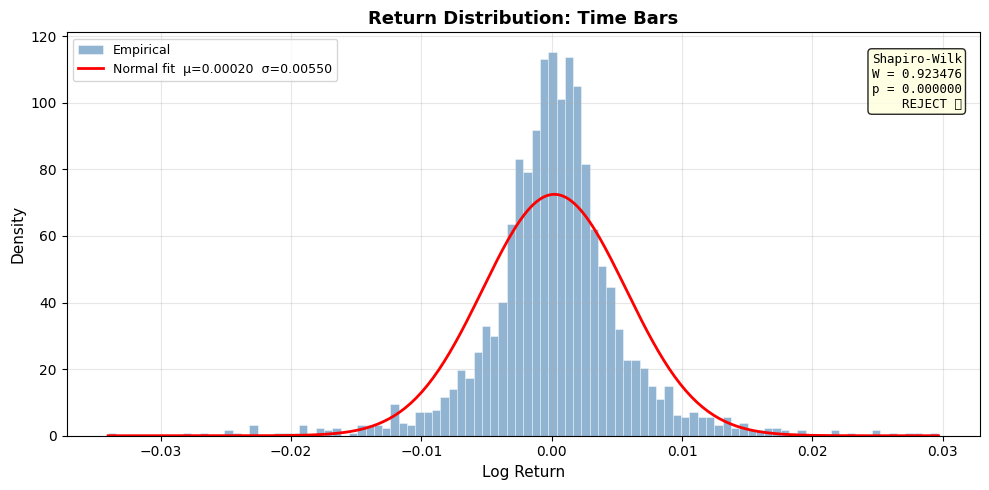

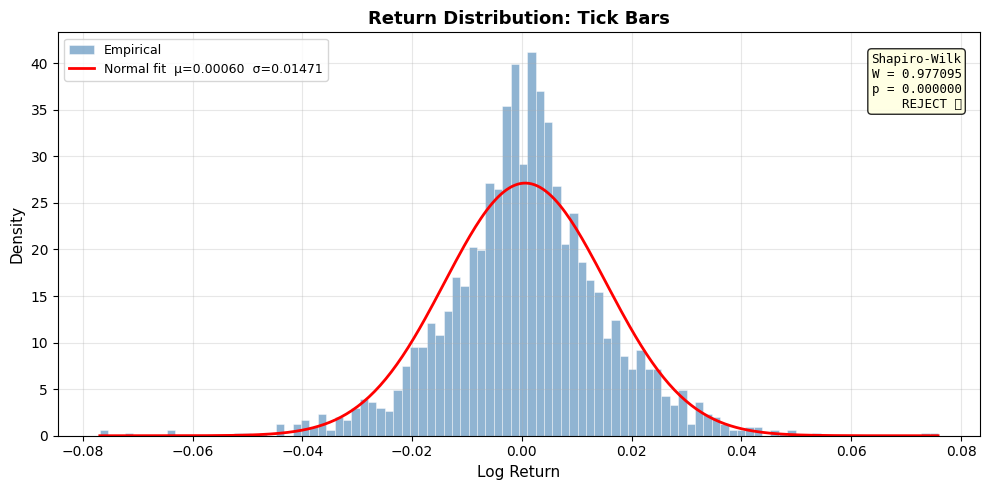

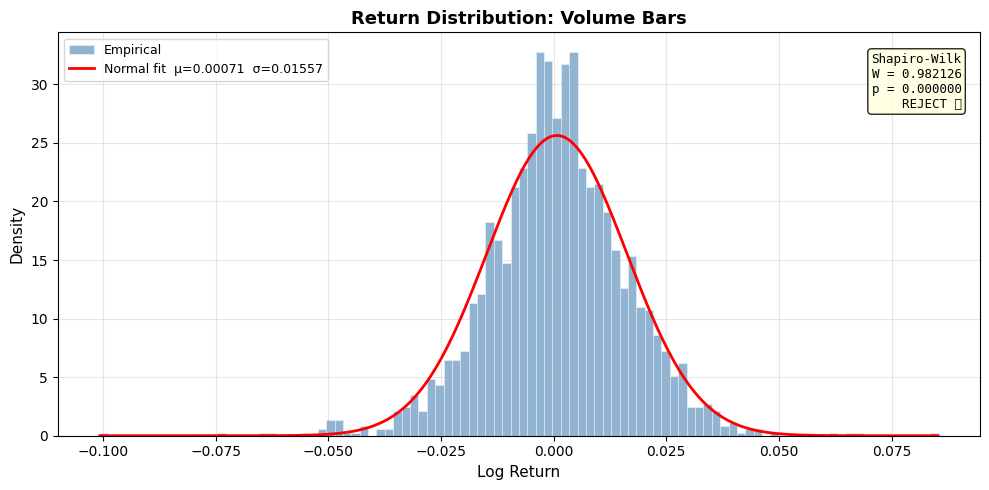

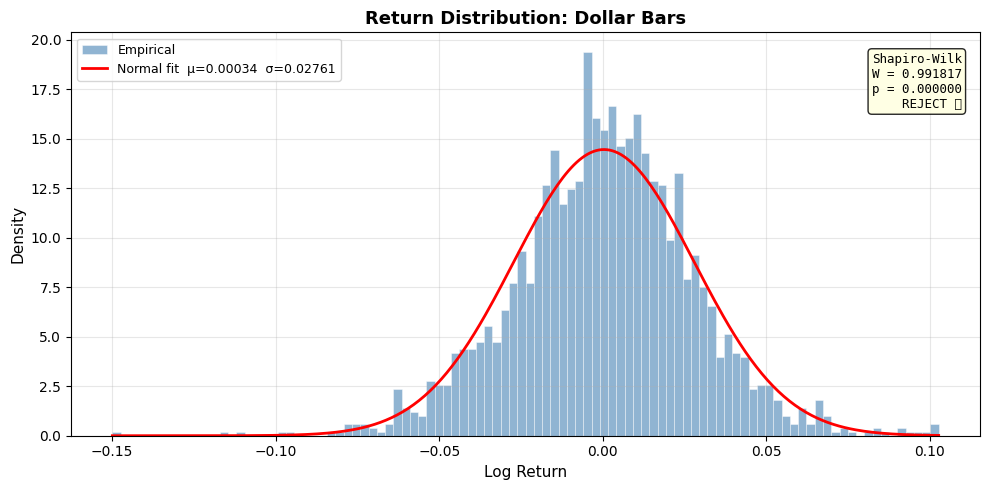

In [6]:
plot_return_distributions(series_dict)


Dollar bars score the highest Shapiro-Wilk statistic at 0.9918, and the histograms confirm this visually. The return distribution histogram matches the normal fit line the closest. 

A QQ-plot (Quantile-Quantile plot) compares the distribution of our log returns directly against what a perfectly normal distribution would look like. The x-axis represents the theoretical quantiles of a normal distribution, and the y-axis represents the actual quantiles of our data. If the returns were perfectly normal, every point would fall exactly on the diagonal reference line. Deviations from that line reveal where our distribution departs from normality. Heavy tails, which are common in financial returns, appear as points that curve away from the line at both ends.

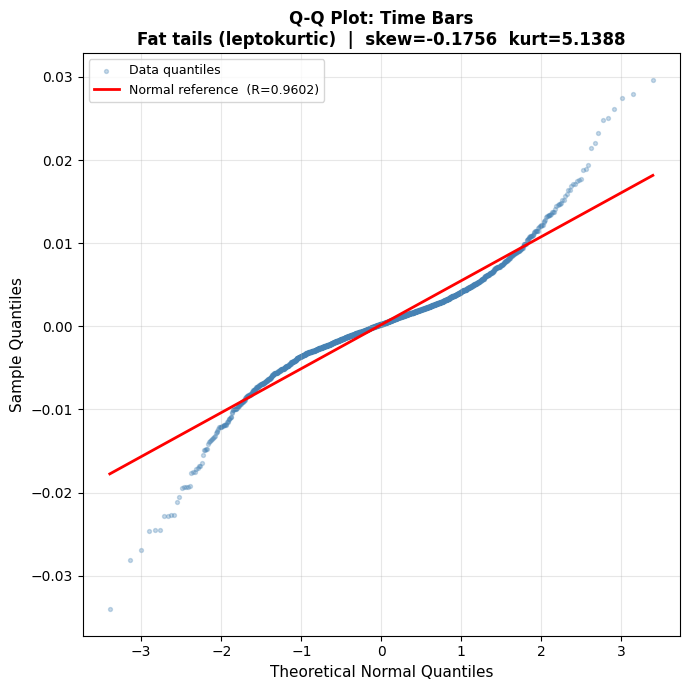

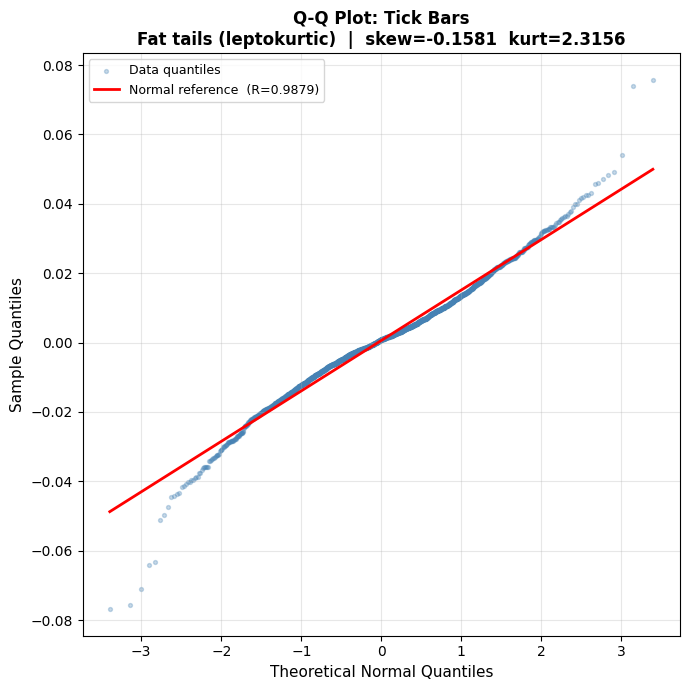

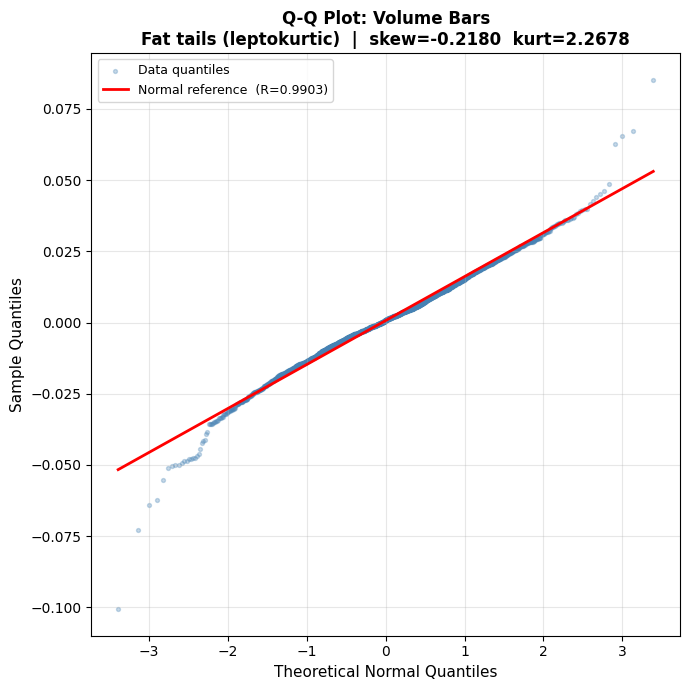

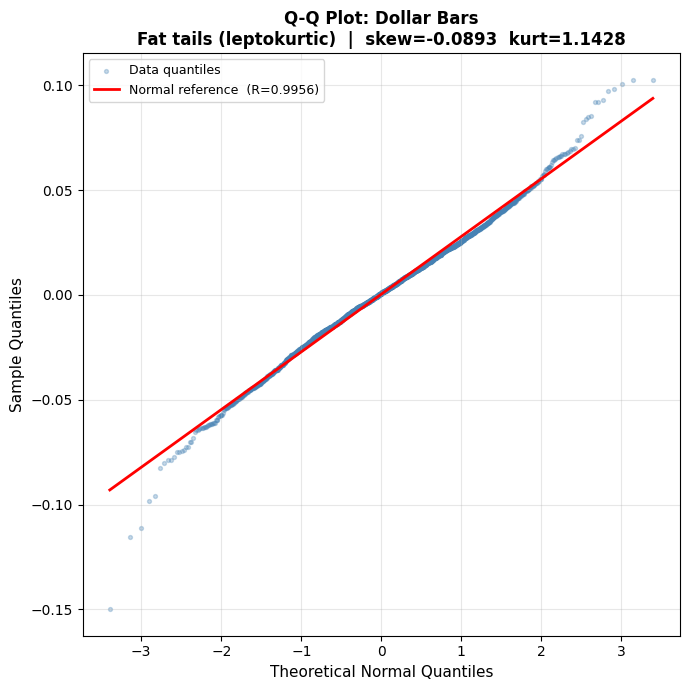

In [7]:
plot_qq_plots(series_dict)

As with the histograms, dollar and volume bars show the best fitting quantiles in the QQ-plots, staying closer to the reference line than time or tick bars across most of the distribution, with dollar bars taking the lead.

# Testing Independence of Log Returns

Testing for independence can inform us if any previous log return has a correlation with the current return, otherwise known as an autocorrelation. The Ljung-Box test assumes the data is independent (the null hypothesis). We then look for evidence strong enough to reject that assumption. The less evidence we find against independence, the more independent our returns are considered to be.

Independence is preferred when training models, since autocorrelation can lead to overfitting. Machine learning models also assume observations are independent. Ideally the more independent our data is, the better. Like with testing normality, our test results are not too insightful themselves and will only be used to see how dependent the log returns of each sampling method are when compared to one other.
Visually we will use ACF plots to see how independent the bars are. The sample size for the plots will be equal to the bar returns with the smallest size, this is so the confidence interval is the same size for visualization.

We can use the Ljung-Box test to compare the dependency of lags between log returns of the different bars. The null hypothesis assumes that the data is independently distributed. A p-value below 0.05 leads us to reject the null hypothesis of independence. A p-value above 0.05 means we fail to reject it, and the data is considered independent at that lag.

Since we are running the Ljung-Box test on the whole dataset, giving many P-values, we will use the mean and median results to compare.

In [8]:
from src.statistics import compare_independence

bar_returns = {
    'Time': time_returns,
    'Tick': tick_returns,
    'Volume': volume_returns,
    'Dollar': dollar_returns
}

comparison_df = compare_independence(bar_returns)

first_half = ['mean_p_value', 'median_p_value', 'mean_test_statistic', 'dependent_lags']
second_half = ['independent_lags', 'first_dependent_lag', 'independence_rank']

print(comparison_df[first_half].to_string(float_format=lambda x: f'{x:.5f}'))
print()
print(comparison_df[second_half].to_string(float_format=lambda x: f'{x:.5f}'))

        mean_p_value  median_p_value  mean_test_statistic  dependent_lags
Dollar       0.19390         0.17623             18.71262         6.00000
Volume       0.05953         0.04631             21.86307        14.00000
Tick         0.01886         0.00258             31.38296        21.00000
Time         0.00000         0.00000             93.51406        25.00000

        independent_lags  first_dependent_lag  independence_rank
Dollar          19.00000             19.00000            1.00000
Volume          11.00000              1.00000            2.00000
Tick             4.00000              1.00000            3.00000
Time             0.00000              1.00000            4.00000


Time and Tick bars show the most dependency between log returns across nearly all lags. Both rejecting the assumption that the returns are independent. Volume bars sit right on the line, as the mean P-value of 0.0595 show independence barely exceeding our significance level of 0.05, while the median value of 0.046 rejects independence. Dollar bars however show independence in both mean and median P-values of 0.194 and 0.176 respectively, both far exceeding our significance level of 0.05.

An ACF plot (Autocorrelation Function plot) shows the correlation between the current return and each of its past values, called lags. The x-axis shows the lag number, and the y-axis shows the strength of the correlation at that lag. The shaded region represents the 95% confidence interval. Any bar that falls outside this region suggests a statistically significant correlation at that lag, meaning the returns are not fully independent. The fewer bars outside the confidence interval, the more independent the returns are considered to be.

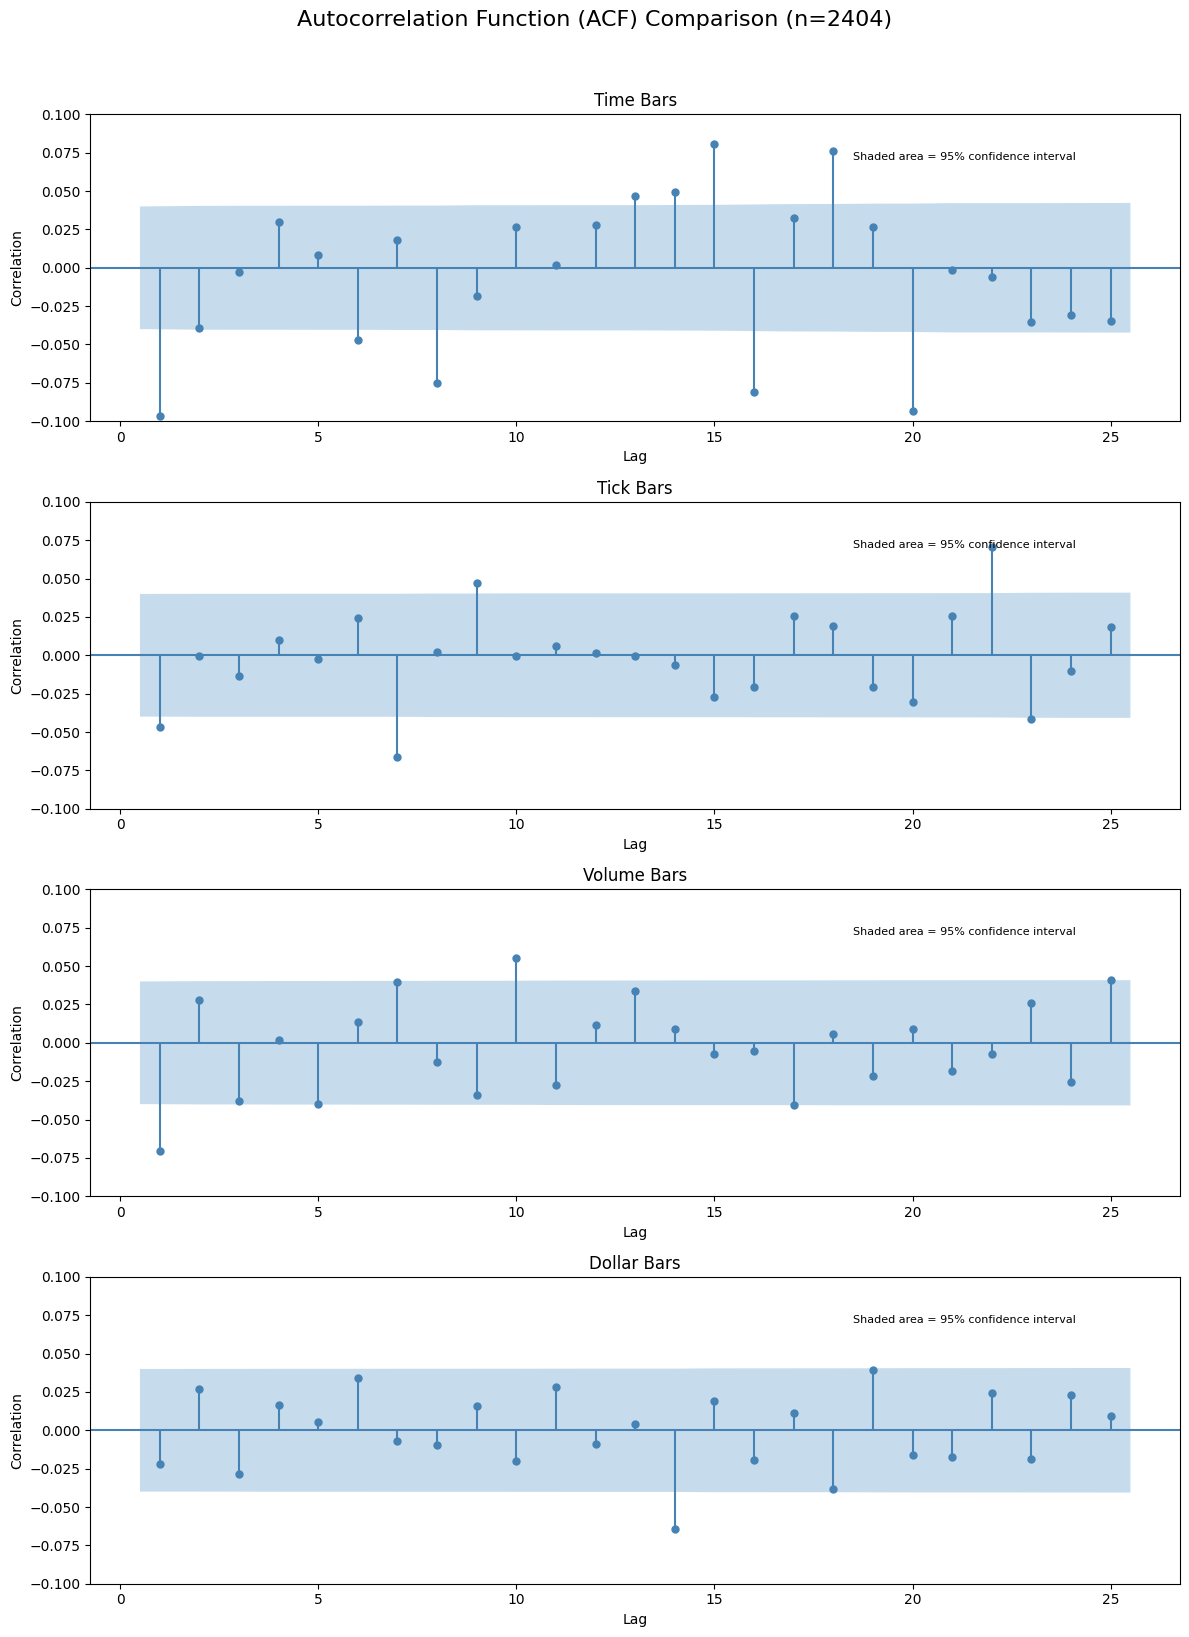

In [9]:
from src.visualization import plot_acf_comparison

plot_acf_comparison(bar_returns)

The ACF plots reinforce the Ljung-Box findings visually. Dollar bars show only 1 lag outside the 95% confidence interval, while time bars show 9. Time bar returns are heavily influenced by their recent history, which means consecutive bars are not truly independent observations. Dollar bars behave much closer to independent draws, which is exactly what machine learning models assume.

Across all measures, dollar bars consistently show the most independent returns, with time bars showing the least. This confirms that the choice of bar type has a direct impact on how much historical information bleeds into the current observation.

# Testing Stability of Log Returns

Stability testing asks whether the data behaves consistently over time. A stable series means the statistical properties remain the same throughout the dataset, where an unstable series shows variations in average return, size of move, and other general behavior. A stable series, when used for modeling, will ensure that the model's performance will hold. Of the three properties tested in this article, stability is the most consequential. A model can be adjusted for non-normal data and mild autocorrelation, but a model trained on unstable data is learning patterns from a regime that may no longer exist by the time it trades.
To measure stability, we look at how the mean and volatility of returns vary across the dataset. If these stay consistent over time, the data is considered stable. We are not expecting any bar type to be perfect, as financial markets, especially crypto, are not perfectly stable. What we do want to know is which bar sampling method has the most stability, and we can find this using a few tests.

We will use ADF for stationarity testing, ARCH LM for constant variance, Rolling CV for consistency over the full dataset, and Levene test to find any shifts between the first and second half of the sample. The more tests a bar type passes, the more stable its returns are considered to be.
 
The Augmented Dickey-Fuller (ADF) test checks whether the series has a tendency to wander without returning to a stable average, which is called a unit root. A series with a unit root has no consistent mean to model around, making it unreliable for prediction. A p-value below 0.05 means we reject the possibility of a unit root, confirming the series is stationary. In other words, a stationary series is like a rubber band that always snaps back to center, while a series with a unit root has no center to return to, drifting wherever the last move took it.

The ARCH LM test checks whether volatility clusters over time. In financial data this is common, where calm periods are followed by more calm periods, and volatile periods are followed by more volatile periods. The null hypothesis assumes variance is constant. A p-value below 0.05 means we reject this, and volatility clustering is present. For modeling, we want variance to be as consistent as possible, so a higher p-value is preferred.

The Rolling Coefficient of Variation (CV) measures how much the mean and standard deviation of returns change across a rolling window of 30 bars. The CV is calculated by dividing the standard deviation of the rolling statistic by its mean. A higher CV means the statistic is more spread out relative to its average, indicating more instability. A lower CV means the statistic stays closer to its average over time. Rather than a single summary statistic, this tracks whether the character of the data stays consistent as time passes. We use thresholds of 1.0 for mean CV and 0.5 for volatility CV, where values below these indicate stability.

The Levene test checks whether the variance of returns in the first half of the dataset is statistically equal to the variance in the second half. This is a simple check for regime change. If the spread of returns shifted significantly between the two periods, the data may behave differently in the future than it did in the past. We use Levene specifically rather than simpler alternatives because it is robust to non-normal distributions, which is important given that we already know none of our bar types produce normally distributed returns. A p-value below 0.05 means variance shifted between halves.

With these four tests defined, we can now run them across all four bar types and compare the results:

In [10]:
from src.statistics import test_log_return_stability

def compare_stability(bar_returns: dict, 
                      significance_level: float = 0.05,
                      rolling_window: int = 30) -> pd.DataFrame:
    rows = []
    
    for bar_type, returns in bar_returns.items():
        result = test_log_return_stability(
            returns,
            significance_level=significance_level,
            rolling_window=rolling_window
        )
        
        rows.append({
            "Bar Type"      : bar_type,
            "Stationary"    : "✓" if result["adf_test"]["is_stationary"] 
                              else "✗",
            "ADF p-value"   : round(result["adf_test"]["p_value"], 4),
            "ARCH Effects"  : "✗" if result["arch_test"]["has_arch_effects"] 
                              else "✓",
            "ARCH p-value"  : round(result["arch_test"]["p_value"], 4),
            "Mean CV"       : round(result["rolling_stability"]["rolling_mean_cv"], 3),
            "Vol CV"        : round(result["rolling_stability"]["rolling_std_cv"], 3),
            "Var Stable"    : "✓" if result["structural_break"]["levene_test"]["equal_variance"] 
                              else "✗",
            "Levene p-value": round(result["structural_break"]["levene_test"]["p_value"], 4),
            "Score"         : result["overall_stability"]["stability_score"],
            "Verdict"       : result["overall_stability"]["verdict"],
        })
    
    return pd.DataFrame(rows).set_index("Bar Type")

In [11]:
import pandas as pd
import numpy as np
from src.statistics import compare_stability
import warnings
from statsmodels.tools.sm_exceptions import InterpolationWarning

with warnings.catch_warnings():
    warnings.simplefilter("ignore", InterpolationWarning)
    stability_comparison = compare_stability(bar_returns)

print(stability_comparison.to_string())

         Stationary  ADF p-value ARCH Effects  ARCH p-value  Mean CV  Vol CV Var Stable  Levene p-value Score            Verdict
Bar Type                                                                                                                        
Time              ✓          0.0            ✗           0.0   21.305   0.668          ✗          0.0000   1/5           Unstable
Tick              ✓          0.0            ✗           0.0    8.508   0.405          ✗          0.0000   2/5  Moderately Stable
Volume            ✓          0.0            ✗           0.0    9.028   0.384          ✗          0.0183   2/5  Moderately Stable
Dollar            ✓          0.0            ✗           0.0    5.415   0.344          ✗          0.0000   2/5  Moderately Stable


All four bar types passed the ADF test with p-values effectively at zero, rejecting the possibility of a unit root. This is expected when using log returns. By measuring the change in price rather than the price level itself, log returns remove any trend in Bitcoin prices that would otherwise cause a unit root. A stationary series is the minimum requirement for meaningful statistical modeling. While stationarity is expected from log returns, confirming it formally rules out any edge cases where the bar construction itself could introduce drift, such as gaps or irregular sampling near market events.

The ARCH test tells us every bar type failed and each one shows significant volatility clustering. Since the null hypothesis assumes the variance is constant over time, and the p-value for each bar lies below our significance level of 0.05, this means log returns and bar sampling alone cannot get rid of volatility clustering within the data. This may also reflect the high volatile period of Bitcoin the data contains. Addressing volatility clustering requires methods outside of aggregation alone, which motivates the CUSUM filter mentioned in Advances in Financial Machine Learning, which we will explore in the next article.

The Rolling Coefficient of Variation (CV) test is where the most meaningful differences appear. We want our mean and volatility CV to be low, as our targets are < 1.0 and < 0.5 respectively. None of the sampling methods achieved a low enough mean CV to pass our threshold of 1.0, reflecting the genuine regime changes across our five year sample. However, dollar bars show a Mean CV of 5.415, which is 60% lower than time bars (21.305) and meaningfully better than both tick (8.508) and volume bars (9.028). For Volatility CV, dollar bars lead as well with the lowest of 0.344, with tick and volume bars close behind at 0.405 and 0.384. Time bars fail this threshold entirely at 0.668.

All four bar types show a significant structural break in variance between the first and second half of the sample. Given that our first half covers 2020–2022 (COVID crash through bear market) and our second half covers 2022–2025 (2024 bull run), these results are not surprising, as these are completely different volatility regimes. Volume bars show the weakest rejection of the test with a p-value of 0.0183, while the other three bar types reject at effectively zero. None pass the test, but volume bars absorb some of the variance shift between the two periods.

In summary, the stability results confirm that dollar bars produce the most stable log returns of the four methods tested. The shared failures across all bar types show genuine market conditions rather than issues resulting from the sampling method alone. With a shared score of 2/5 between tick, volume, and dollar bars, the CV numbers show a real difference between them. On every metric where differences exist, dollar bars lead.

To visualize this, the rolling mean and rolling standard deviation are plotted across the full sample for each bar type. A flat line indicates a stable series, while large swings indicate instability.

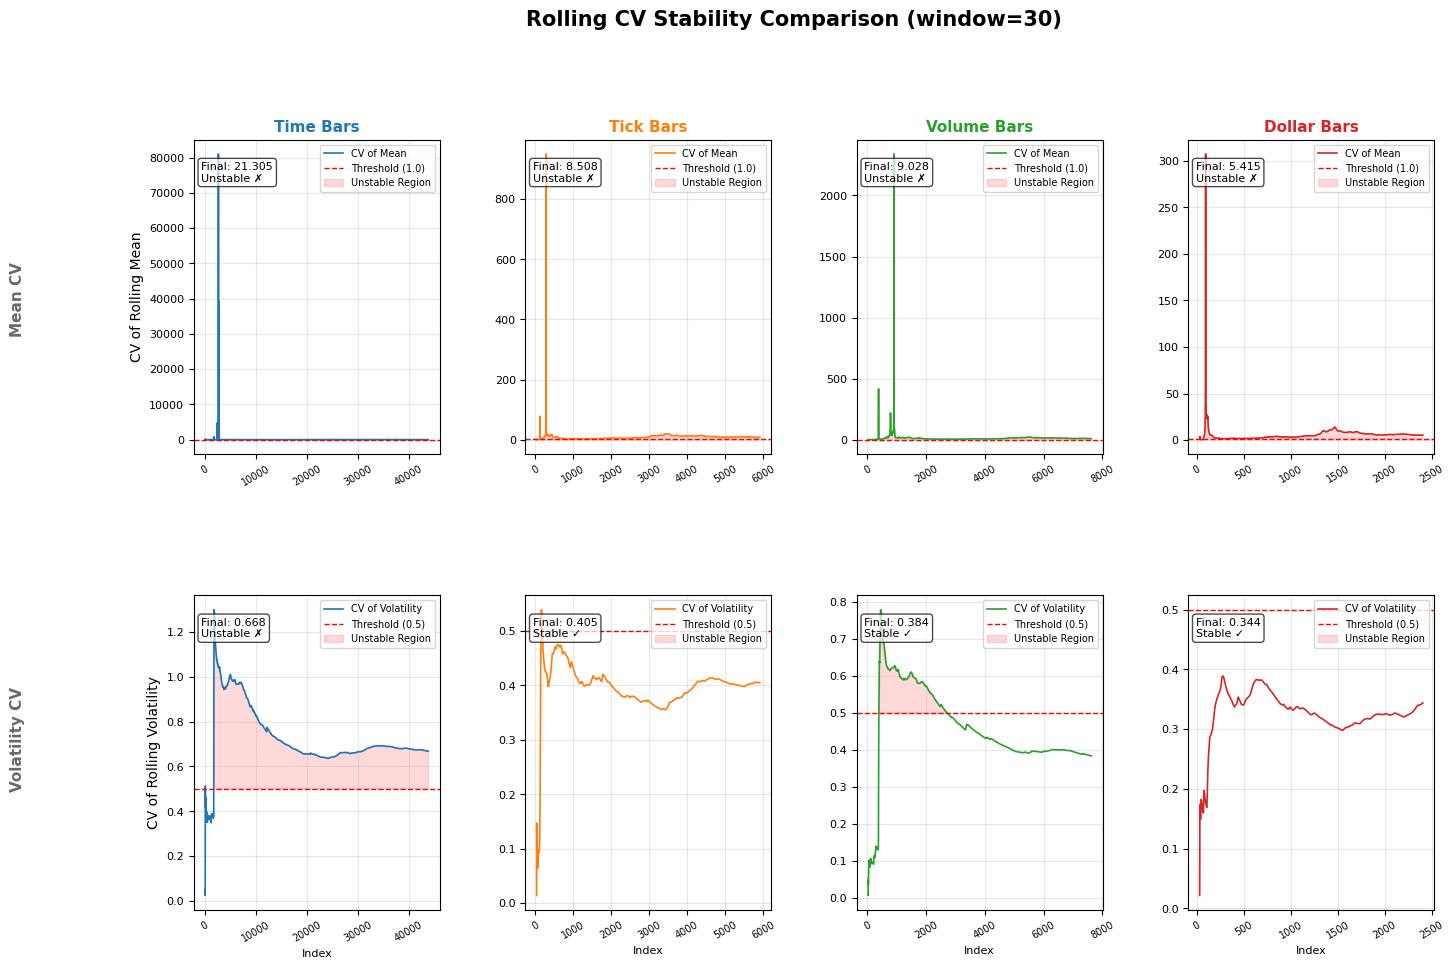

In [12]:
from src.visualization import plot_rolling_cv_comparison

bar_returns = {
    "Time Bars":   time_returns,
    "Tick Bars":   tick_returns,
    "Volume Bars": volume_returns,
    "Dollar Bars": dollar_returns,
}

plot_rolling_cv_comparison(bar_returns, rolling_window=30)

The rolling plots confirm what the numbers show. All four bar types show a large spike in rolling mean near the beginning of the sample, which corresponds to the COVID crash of March 2020 and the extreme volatility that followed. After this spike, the rolling mean of time bars continues to swing more dramatically than any other method, consistent with its Mean CV of 21.305. Dollar bars show the flattest rolling mean trajectory across the full sample, which is a direct visual representation of its lower Mean CV of 5.415. For rolling standard deviation, dollar bars are the only bar type that stays clearly below the 0.5 threshold throughout most of the sample. Time bars cross the threshold frequently, reflecting the inconsistent volatility that fixed-interval sampling produces when market activity varies significantly from bar to bar.

Across all four tests, dollar bars consistently show the most stable properties, confirming that sampling by economic activity produces returns that behave more consistently over time than sampling by clock time, trade count, or volume alone.

# Conclusion

This article was intended to test whether the method used to aggregate raw tick data into bars affects the statistical properties of their log returns. Across three properties and four bar types, dollar bars consistently come out ahead. 

On normality, no bar type produces returns that could be drawn from a normal distribution, which is expected for any financial asset and especially for Bitcoin over 5 years of high extreme prices moves. The Shapiro-Wilk statistic and distribution plots show a clear ranking. Time bars score the lowest at 0.923, while dollar bars score the highest at 0.992, sitting closest to the normal distribution of any method tested. The histograms and QQ-plots confirm this visually, with dollar bars returns fitting the normal line more closely than any other method. 

For independence, the differences are the most pronounced of all three properties. Time bars reject independence at every lag tested, with a mean Ljung-Box p-value effectively at zero and 9 lags outside the 95% confidence interval in the ACF plots. Dollar bars show a mean p-value of 0.194 and only 1 lag outside the confidence interval, making them the only bar type that comfortably fails to reject the assumption of independence. The autocorrelation visible in time bar returns is a result of sampling at fixed time intervals, where slow  and active periods are treated as equal observations. Dollar bars remove most of this by sampling based on activity rather than time. 

On stability, the results are more nuanced. All four bar types fail the ARCH test and the Levene test, which reflects the volatility regimes in our sample. What the rolling CV numbers show, however, is a clear separation. Dollar bars produce a mean CV of 5.415, which is 60% lower than time bars and the best of all four methods. The rolling volatility CV of 0.344 is again the lowest of any bar type tested. On every metric where meaningful differences exist, dollar bars take the lead. The instability that remains across all bar types is not something bar sampling alone can solve, and this is where the CUSUM filter becomes relevant.

Taken together, these results support what Lopez De Prado argues in Advances in Financial Machine Learning. Dollar bars produce returns that are more normal, more independent, and more stable than time bars, and they outperform tick and volume bars across most metrics as well. They do not produce perfect data, and no sampling method will. But they produce meaningfully better data, and in quantitative finance, quality data is the foundation that everything else is built on. 

With the instabilities that remain in volatility clustering and with structural breaks among all bar types, our next step is to see how we can minimize this instability further by comparing how we sample within the Dollar bar method alone. For example, our threshold used here for sampling was a static $100 million for the whole 5 years of data. In my next article, I would like to test different thresholds and sampling methods, including the symmetric CUSUM filter, and compare their stability.
